# Part 1: Bare-metal Hello World on the QEMU `virt` machine

## 0. Project setup

We set up a `uv` project in this repo to give us Jupyter bash kernel support.

Run the following command to install the Jupyter bash kernel:

```bash
uv run python -m bash_kernel.install --sys-prefix
```

Then, in VS Code, select the Jupyter bash kernel for your notebook:

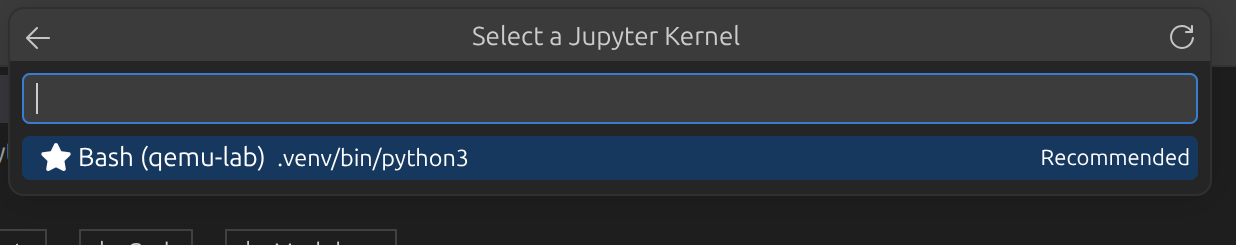

We also ensure that the following `apt` packages are installed on the host system:

```bash
sudo apt-get install build-essential gcc-aarch64-linux-gnu qemu-system-arm bat
```

## 1. Source Files

The source files for our initial program are as follows:

- `main.c`: The main source file containing the entry point of the program.
- `start.S`: The assembly source file containing the startup code, which sets up the execution environment before transferring control to `main.c`.
- `link.ld`: The linker script that defines the memory layout of the program.
- `Makefile`: Contains the build instructions for compiling the source files and linking them into an executable.
- `run.sh`: Host script to launch QEMU with the appropriate machine and our bare-metal binary.

Critically, `link.ld` places the startup code at address `0x40000000`, which is where QEMU's `virt` machine expects the CPU to start execution.

### 1.1. Makefile

We create a script to launch QEMU with the `virt` machine and our bare-metal Hello World binary:

In [1]:
batcat --terminal-width 110 -r 1:4 Makefile

───────┬──────────────────────────────────────────────────────────────────────────────────────────────────────
       │ File: Makefile
───────┼──────────────────────────────────────────────────────────────────────────────────────────────────────
   1   │ # Compiler for AArch64 targets: install via:
   2   │ #   sudo apt install gcc-aarch64-linux-gnu
   3   │ CC = aarch64-linux-gnu-gcc
   4   │ 
───────┴──────────────────────────────────────────────────────────────────────────────────────────────────────


In [2]:
batcat --terminal-width 110 -r 5:15 Makefile

───────┬──────────────────────────────────────────────────────────────────────────────────────────────────────
       │ File: Makefile
───────┼──────────────────────────────────────────────────────────────────────────────────────────────────────
   5   │ # -march=armv8-a: Target the ARMv8-A ISA (Instruction Set Architecture) regardless of host default
   6   │ # -mabi=lp64: 64-bit pointers/longs (the standard AArch64 ABI, Application Binary Interface)
   7   │ # -mgeneral-regs-only: Forbid floating-point/SIMD codegen; CPACR_EL1 is never configured to
   8   │ #     enable it
   9   │ # -mstrict-align: Don't assume unaligned accesses work before alignment checking is configured
  10   │ # -ffreestanding: Do not link against the standard library
  11   │ # -fno-stack-protector: Disable stack protection
  12   │ # -fno-pic: Disable position-independent code generation
  13   │ CFLAGS = -march=armv8-a -mabi=lp64 -mgeneral-regs-only -mstrict-align \
  14   │     -ffreestanding -fno-stack-pr

In the above, we target the [ARMv8-A](https://en.wikipedia.org/wiki/ARM_architecture_family#Armv8-A) architecture using the AArch64 instruction set.  For the
application binary interface, we chose the 64-bit one, `lp64`:

In [3]:
aarch64-linux-gnu-gcc --help=target | grep -A2 mabi

  -mabi=                      Generate code that conforms to the specified ABI.
  -march=                     Use features of architecture ARCH.
  -mbig-endian                Assume target CPU is configured as big endian.
--
  Known AArch64 ABIs (for use with the -mabi= option):
    ilp32 lp64



The `-mgeneral-regs-only` option forbids floating-point and SIMD code generation.  Enabling these
would require setting the matching bits in the [`CPACR_EL1` system register](https://support.arm.com/documentation/111107/2026-06/AArch64-Registers/CPACR-EL1--Architectural-Feature-Access-Control-Register?lang=en) (bits 21 and 20, `FPEN`), but we don't need to do that for our purposes.

In [4]:
batcat --terminal-width 110 -r 16:20 Makefile

───────┬──────────────────────────────────────────────────────────────────────────────────────────────────────
       │ File: Makefile
───────┼──────────────────────────────────────────────────────────────────────────────────────────────────────
  16   │ # -nostdlib: Do not link against the standard library
  17   │ # -static: Create a statically linked executable
  18   │ # -Wl,-T,link.ld: Pass the linker script link.ld to the linker
  19   │ LDFLAGS = -nostdlib -static -Wl,-T,link.ld
  20   │ 
───────┴──────────────────────────────────────────────────────────────────────────────────────────────────────


The linker, which combines object files into an executable, is responsible for resolving symbol references and arranging code and data in memory. The `-T` option specifies the linker script to use, which controls the memory layout of the output executable.

In [5]:
batcat --terminal-width 110 -r 21: Makefile

───────┬──────────────────────────────────────────────────────────────────────────────────────────────────────
       │ File: Makefile
───────┼──────────────────────────────────────────────────────────────────────────────────────────────────────
  21   │ start.elf: start.S main.c link.ld
  22   │     $(CC) $(CFLAGS) $(LDFLAGS) -o $@ start.S main.c
  23   │ 
  24   │ clean:
  25   │     rm -f start.elf
  26   │ 
  27   │ .PHONY: clean
───────┴──────────────────────────────────────────────────────────────────────────────────────────────────────


### 1.2. QEMU Launch Script

In [6]:
batcat --terminal-width 110 run.sh

───────┬──────────────────────────────────────────────────────────────────────────────────────────────────────
       │ File: run.sh
───────┼──────────────────────────────────────────────────────────────────────────────────────────────────────
   1   │ #!/usr/bin/env bash
   2   │ set -euo pipefail
   3   │ 
   4   │ cd "$(dirname "$0")"
   5   │ make
   6   │ 
   7   │ exec qemu-system-aarch64 \
   8   │     -M virt \
   9   │     -nodefaults \
  10   │     -cpu max \
  11   │     -serial vc \
  12   │     -kernel start.elf
───────┴──────────────────────────────────────────────────────────────────────────────────────────────────────


Here, we invoke `qemu-system-aarch64` specifically to use an `aarch64` target architecture, and
`-M virt` specifies the machine type as `virt`, which is a versatile platform for running ARM
virtual machines in QEMU.

`-nodefaults` tells QEMU not to create default devices, thus only the specified `-serial vc` device
will be created for serial output.

`-cpu max` tells QEMU to emulate the maximum available CPU features for the chosen architecture.
Finally, `-kernel start.elf` specifies the kernel image to be loaded and executed by QEMU.

### 1.3 `start.S`

In [7]:
batcat --terminal-width 110 start.S

───────┬──────────────────────────────────────────────────────────────────────────────────────────────────────
       │ File: start.S
───────┼──────────────────────────────────────────────────────────────────────────────────────────────────────
   1   │ .section ".text.boot"
   2   │ .global _start
   3   │ 
   4   │ _start:
   5   │     # Load the address of the top of the stack into x0
   6   │     ldr x0, =stack_top
   7   │     # Copy the value in x0 to the stack pointer (sp)
   8   │     mov sp, x0
   9   │     # Branch (with link) to the main function
  10   │     bl  main
  11   │     # main returns here
  12   │ hang:
  13   │     # Wait for event
  14   │     wfe
  15   │     # Branch to hang (infinite loop)
  16   │     b   hang
───────┴──────────────────────────────────────────────────────────────────────────────────────────────────────


The `.section` directive specifies a section name, which the linker uses to organize the code and data into different segments. Here, `.section ".text.boot"` is a special section we use to ensure that the boot code is placed at the **beginning** of the text segment, which is critical for the proper initialization of the system.

The `.global` directive is used to declare a symbol as global. In this case, the `_start` symbol is used in the linker script (`link.ld`) to indicate the entry point of the program:

```
ENTRY(_start)
```

The `_start` block above defines the entry-point logic: initialize the stack pointer (where `stack_top` is defined by `link.ld`), then jump to the `main` function in our C code.  In particular, `bl` sets up a return address so that when `main` finishes, control can return to the instruction following the `bl` in `_start`.

This is the `hang` block, which consists of an infinite loop, ensuring that CPU execution does not proceed beyond this point once the main program has finished. `wfe` stands for "Wait For Event", which puts the CPU into a low-power state until an event occurs, effectively halting execution in a power-efficient manner.

### 1.4 Linker Script (`link.ld`)

In [8]:
batcat --terminal-width 110 link.ld

───────┬──────────────────────────────────────────────────────────────────────────────────────────────────────
       │ File: link.ld
───────┼──────────────────────────────────────────────────────────────────────────────────────────────────────
   1   │ ENTRY(_start) /** Entry point defined in start.S */
   2   │ 
   3   │ SECTIONS
   4   │ {
   5   │     /* QEMU's "virt" machine loads -kernel images at this address */
   6   │     . = 0x40000000;
   7   │ 
   8   │     /* .text.boot comes from start.S and must be aligned to
   9   │     0x40000000, thus it comes first in our section ordering. */
  10   │ 
  11   │     .text : { *(.text.boot) *(.text*) }
  12   │     /* Explictly placed, so that it doesn't get auto-assigned before .text */
  13   │     .note.gnu.build-id : { *(.note.gnu.build-id) }
  14   │ 
  15   │     /* All other sections come from main.c or are left empty. */
  16   │     .rodata : { *(.rodata*) }
  17   │     .data : { *(.data*) }
  18   │     .bss : { *(.bss*) *

Here, the `.` value in the linker script represents the current location counter, which keeps track of the current address in the output file. Our first use of it is to set the starting address of the program:

```
. = 0x40000000;
```

Since only `start.S` writes to the `.text.boot` section, which is defined to come first in the linker output, this ensures our boot code is placed at the very beginning of the program's memory layout.  We can verify that `0x40000000` is correct for our target machine as follows:

In [9]:
# Use the special `dumpdtb` machine option to write the device tree blob to a file
qemu-system-aarch64 -M virt -cpu max -nographic\
    -machine dumpdtb=/tmp/virt.dtb \
    -kernel /dev/null 2>&1 | tail -1

# Convert the dumped device tree blob to a human-readable format and extract the memory node
dtc -I dtb -O dts /tmp/virt.dtb 2>/dev/null | grep -A3 'memory@'

qemu-system-aarch64: info: dtb dumped to /tmp/virt.dtb. Exiting.
	memory@40000000 {
		reg = <0x00 0x40000000 0x00 0x8000000>;
		device_type = "memory";
	};


### 1.5 `main.c`

The main program, defined in `main.c`, writes "Hello, World!" to the serial port we defined in our `run.sh` script (`-serial vc`).  To find the correct address of the serial port, we refer to the device tree we dumped earlier:

In [10]:
dtc -I dtb -O dts /tmp/virt.dtb 2>/dev/null | grep -A3 'pl011@'

	pl011@9000000 {
		clock-names = "uartclk\0apb_pclk";
		clocks = <0x8000 0x8000>;
		interrupts = <0x00 0x01 0x04>;
--
		stdout-path = "/pl011@9000000";
		rng-seed = <0x9a23796c 0xfa3f105f 0x3192787e 0xb8efaec5 0xf747d6d3 0xe4ace42c 0x2784f067 0x62e6245f>;
		kaslr-seed = <0x8f5b26b4 0xaaf6ee22>;
	};


Here, `pl011` refers to the ARM PrimeCell UART (Universal Asynchronous Receiver/Transmitter) peripheral, which is commonly used for serial communication on ARM-based systems.  The UART protocol defines a [set of registers](https://support.arm.com/documentation/ddi0183/g/programmers-model/summary-of-registers) as offsets from the base address of the UART peripheral:

In [11]:
batcat --terminal-width 110 -r 1:9 main.c

───────┬──────────────────────────────────────────────────────────────────────────────────────────────────────
       │ File: main.c
───────┼──────────────────────────────────────────────────────────────────────────────────────────────────────
   1   │ /* PL011 UART0 base address on the QEMU "virt" machine */
   2   │ #define UART0_BASE 0x09000000UL
   3   │ 
   4   │ /** Data register; writing to this register transmits a character */
   5   │ #define UART0_DR   (*(volatile unsigned int *)(UART0_BASE + 0x00))
   6   │ 
   7   │ /** Flag register; a read-only status register */
   8   │ #define UART0_FR   (*(volatile unsigned int *)(UART0_BASE + 0x18))
   9   │ 
───────┴──────────────────────────────────────────────────────────────────────────────────────────────────────


In particular, the [flag register](https://support.arm.com/documentation/ddi0183/g/programmers-model/register-descriptions/flag-register--uartfr?lang=en) contains status bits that indicate the current state of the UART.  For this program, we only need the `TXFF` (Transmit FIFO Full) bit, which tells us whether the UART is ready to accept new data for transmission.

In [12]:
batcat --terminal-width 110 -r 10:12 main.c

───────┬──────────────────────────────────────────────────────────────────────────────────────────────────────
       │ File: main.c
───────┼──────────────────────────────────────────────────────────────────────────────────────────────────────
  10   │ /** Status mask: transmit buffer full? */
  11   │ #define UART0_FR_TXFF (1 << 5)
  12   │ 
───────┴──────────────────────────────────────────────────────────────────────────────────────────────────────


We define some ANSI escape sequences for printing in color (UART doesn't understand them, and sends them through as raw bytes, but our receiving terminal does):

In [13]:
batcat --terminal-width 110 -r 13:15 main.c

───────┬──────────────────────────────────────────────────────────────────────────────────────────────────────
       │ File: main.c
───────┼──────────────────────────────────────────────────────────────────────────────────────────────────────
  13   │ #define GREEN   "\033"
  14   │ #define RESET   "\033"
  15   │ 
───────┴──────────────────────────────────────────────────────────────────────────────────────────────────────


Next, define the function for printing a single character to the UART.  This function loops until the `TXFF` (Transmit FIFO Full) bit in the flag register is clear, then sends the character's byte to the data register.

In [14]:
batcat --terminal-width 110 -r 16:24 main.c

───────┬──────────────────────────────────────────────────────────────────────────────────────────────────────
       │ File: main.c
───────┼──────────────────────────────────────────────────────────────────────────────────────────────────────
  16   │ /** Output a character to the UART0 console */
  17   │ static void uart_putc(char c)
  18   │ {
  19   │ 
  20   │     while (UART0_FR & UART0_FR_TXFF)
  21   │         ;
  22   │     UART0_DR = (unsigned int)c;
  23   │ }
  24   │ 
───────┴──────────────────────────────────────────────────────────────────────────────────────────────────────


Next, a convenience function for printing a string, converting newlines as required for the attached terminal:

In [15]:
batcat --terminal-width 110 -r 25:34 main.c

───────┬──────────────────────────────────────────────────────────────────────────────────────────────────────
       │ File: main.c
───────┼──────────────────────────────────────────────────────────────────────────────────────────────────────
  25   │ /** Output a character string to the UART0 console */
  26   │ static void uart_puts(const char *s)
  27   │ {
  28   │     while (*s) {
  29   │         if (*s == '\n')
  30   │             uart_putc('\r');
  31   │         uart_putc(*s++);
  32   │     }
  33   │ }
  34   │ 
───────┴──────────────────────────────────────────────────────────────────────────────────────────────────────


Finally, the main function itself:

In [16]:
batcat --terminal-width 110 -r 35: main.c

───────┬──────────────────────────────────────────────────────────────────────────────────────────────────────
       │ File: main.c
───────┼──────────────────────────────────────────────────────────────────────────────────────────────────────
  35   │ void main(void)
  36   │ {
  37   │     uart_puts(GREEN "Hello, world!\n" RESET);
  38   │ }
───────┴──────────────────────────────────────────────────────────────────────────────────────────────────────


## 2. Running the Program

In [17]:
./run.sh

make: 'start.elf' is up to date.


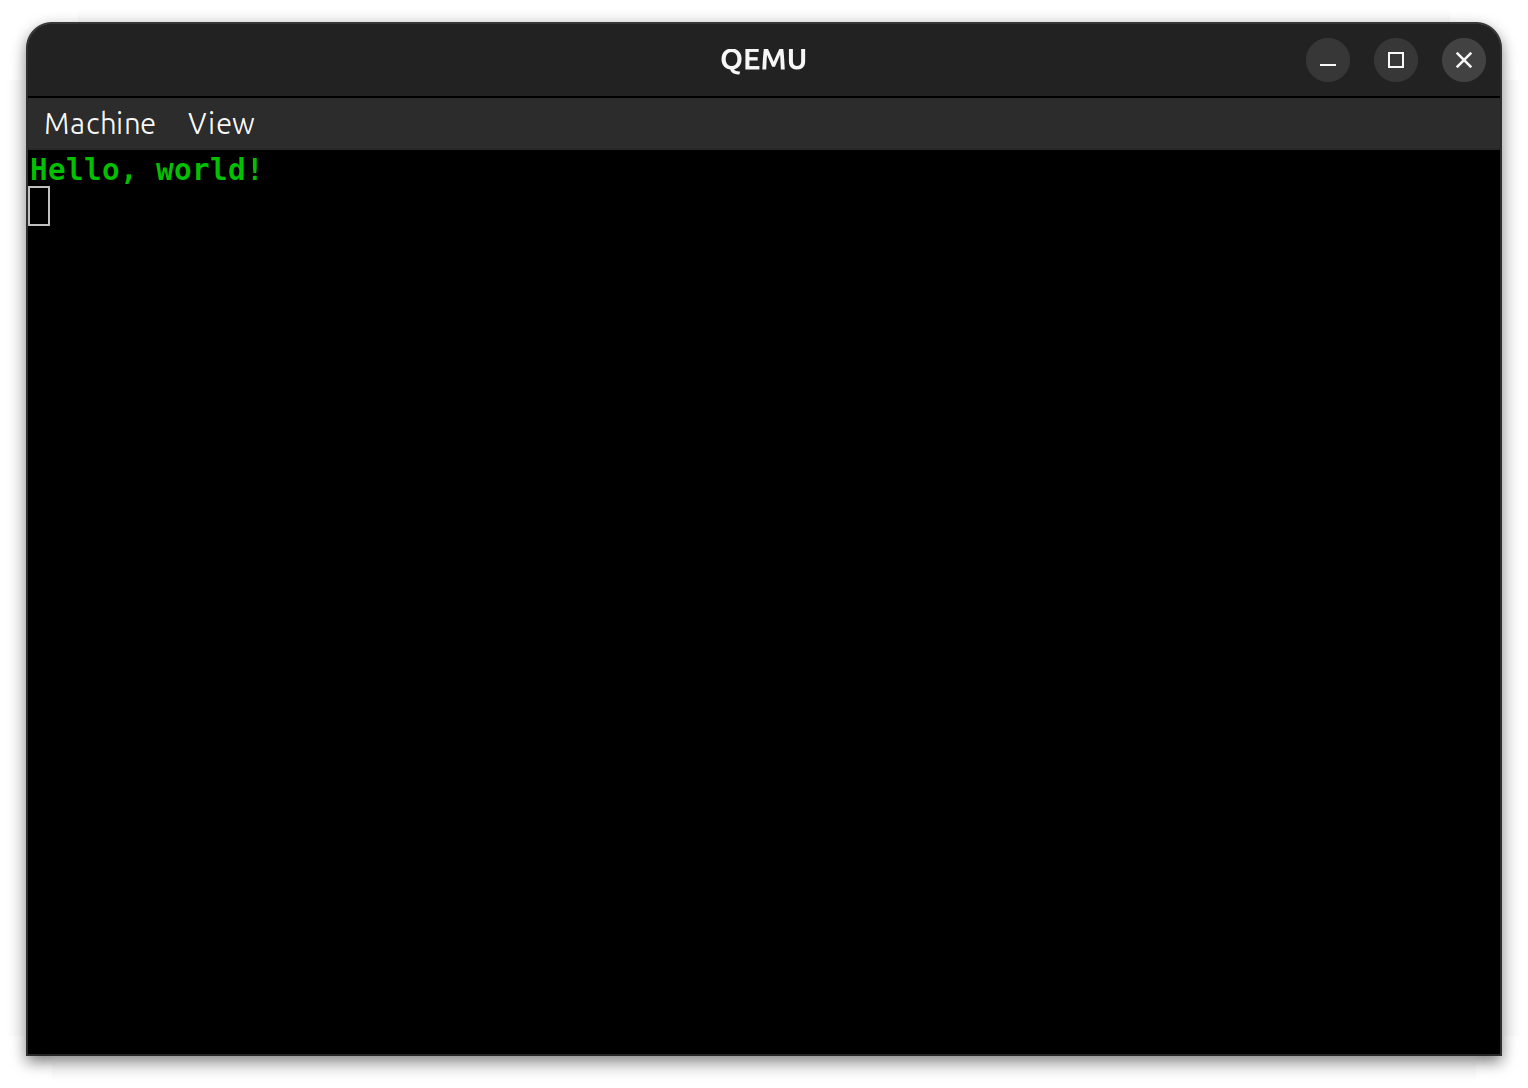

Since `serial0` is the only device defined, QEMU shows a terminal for it by default, where our "Hello World!" message appears. Closing the window terminates the QEMU instance.

# 3. Note regarding the UART

For our QEMU setup, we did not need to worry about configuring clock settings for the UART, as QEMU handles this internally.  For a real setup, we would check the following registers:

- `UARTIBRD` (Integer Baud Rate Divisor)
- `UARTFBRD` (Fractional Baud Rate Divisor)
- `UARTLCR_H` ([Line Control Register](https://support.arm.com/documentation/ddi0183/g/programmers-model/register-descriptions/line-control-register--uartlcr-h?lang=en))
- `UARTCR` ([Control Register](https://support.arm.com/documentation/ddi0183/g/programmers-model/register-descriptions/control-register--uartcr?lang=en))

Note that `UARTCR`'s default is `0x0300`, which typically means the UART is has both transmit and receive functionality (`RXE` and `TXE` bits set), but is not yet enabled (`UARTEN` bit not set).

**Example:** 115200 baud is standard for many UART configurations.  First, we get the clock
frequency as follows:

In [18]:
dtc -I dtb -O dts /tmp/virt.dtb 2>/dev/null | grep -A3 'pl011@'

	pl011@9000000 {
		clock-names = "uartclk\0apb_pclk";
		clocks = <0x8000 0x8000>;
		interrupts = <0x00 0x01 0x04>;
--
		stdout-path = "/pl011@9000000";
		rng-seed = <0x9a23796c 0xfa3f105f 0x3192787e 0xb8efaec5 0xf747d6d3 0xe4ace42c 0x2784f067 0x62e6245f>;
		kaslr-seed = <0x8f5b26b4 0xaaf6ee22>;
	};


From the above output, we determine that the clock frequency for the UART is derived from the `apb-pclk` node:

In [19]:
dtc -I dtb -O dts /tmp/virt.dtb 2>/dev/null | grep -A6 'apb-pclk'

	apb-pclk {
		phandle = <0x8000>;
		clock-output-names = "clk24mhz";
		clock-frequency = <0x16e3600>;
		#clock-cells = <0x00>;
		compatible = "fixed-clock";
	};


The clock frequency is listed as 24 MHz. For a standard 115200 baud rate, the integer and fractional baud rate divisors can be calculated as follows:

In [20]:
python -c "baud_div = 24_000_000 / (16 * 115_200);
n = int(baud_div);
f = round((baud_div - n) * 64);
print(n, f)"

13 1


Thus `UARTIBRD` should be set to 13 and `UARTFBRD` should be set to 1. An example configuration in
`start.S` might include something like the following:

```S
    ldr	x1, =0x09000000		# UART0_BASE
    mov	w2, #0
    str	w2, [x1, #0x30]		# UARTCR: disable UART before reprogramming

    mov	w2, #13
    str	w2, [x1, #0x24]		# UARTIBRD: integer baud-rate divisor

    mov	w2, #1
    str	w2, [x1, #0x28]		# UARTFBRD: fractional baud-rate divisor

    mov	w2, #0x60		# WLEN=0b11 (8 bits), no parity, 1 stop bit
    str	w2, [x1, #0x2c]		# UARTLCR_H: written last, latches IBRD/FBRD

    mov	w2, #0x301		# UARTEN | TXE | RXE
    str	w2, [x1, #0x30]		# UARTCR: enable UART, TX, RX
```